In [1]:
# Cell 1: Generate large synthetic expense dataset

import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# Set seed for reproducibility
np.random.seed(42)
random.seed(42)

n_rows = 500_000  # 500,000 transactions

categories = ['Food', 'Transport', 'Entertainment', 'Utilities', 
              'Healthcare', 'Shopping', 'Education', 'Travel']

payment_methods = ['Credit Card', 'Debit Card', 'Cash', 'UPI', 'Net Banking']

# Generate random dates between 2022 and 2024
start_date = datetime(2022, 1, 1)
end_date = datetime(2024, 12, 31)
date_range = (end_date - start_date).days

dates = [start_date + timedelta(days=random.randint(0, date_range)) 
         for _ in range(n_rows)]

# Build the dataframe
df = pd.DataFrame({
    'date': dates,
    'category': [random.choice(categories) for _ in range(n_rows)],
    'amount': np.round(np.random.exponential(scale=500, size=n_rows), 2),
    'payment_method': [random.choice(payment_methods) for _ in range(n_rows)],
    'user_id': np.random.randint(1, 1001, size=n_rows)  # 1000 users
})

# Save as CSV
df.to_csv('expense_data.csv', index=False)
print(f"Dataset created: {len(df):,} rows")
print(df.head())

Dataset created: 500,000 rows
        date       category   amount payment_method  user_id
0 2022-08-17  Entertainment   234.63    Net Banking      817
1 2022-02-21         Travel  1505.06     Debit Card      567
2 2023-07-18         Travel   658.37     Debit Card      342
3 2023-05-17      Utilities   456.47     Debit Card      397
4 2023-04-03       Shopping    84.81           Cash      279


In [7]:
%pip install "pyarrow>=13.0.0"


Note: you may need to restart the kernel to use updated packages.


In [1]:
# Cell 2: Load with DASK (not pandas!)

import dask.dataframe as dd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV with Dask
ddf = dd.read_csv('expense_data.csv', parse_dates=['date'])

print("Dask DataFrame created (lazy - not computed yet)")
print(f"Number of partitions: {ddf.npartitions}")
print(f"Columns: {list(ddf.columns)}")

Dask DataFrame created (lazy - not computed yet)
Number of partitions: 1
Columns: ['date', 'category', 'amount', 'payment_method', 'user_id']


In [2]:
# Cell 3: Basic info (call compute() to trigger execution)

print("=== DATASET SHAPE ===")
print(f"Rows: {len(ddf):,}")  # len() triggers compute
print(f"Columns: {len(ddf.columns)}")

print("\n=== FIRST 5 ROWS ===")
print(ddf.head())  # head() also triggers compute

print("\n=== DATA TYPES ===")
print(ddf.dtypes)

=== DATASET SHAPE ===
Rows: 500,000
Columns: 5

=== FIRST 5 ROWS ===
        date       category   amount payment_method  user_id
0 2022-08-17  Entertainment   234.63    Net Banking      817
1 2022-02-21         Travel  1505.06     Debit Card      567
2 2023-07-18         Travel   658.37     Debit Card      342
3 2023-05-17      Utilities   456.47     Debit Card      397
4 2023-04-03       Shopping    84.81           Cash      279

=== DATA TYPES ===
date              datetime64[us]
category                  string
amount                   float64
payment_method            string
user_id                    int64
dtype: object


=== TOTAL SPEND BY CATEGORY ===
category
Food             31591176.39
Education        31370455.69
Transport        31326154.01
Travel           31305867.86
Entertainment    31273829.75
Shopping         31201343.56
Healthcare       31121001.23
Utilities        30849395.86
Name: amount, dtype: float64


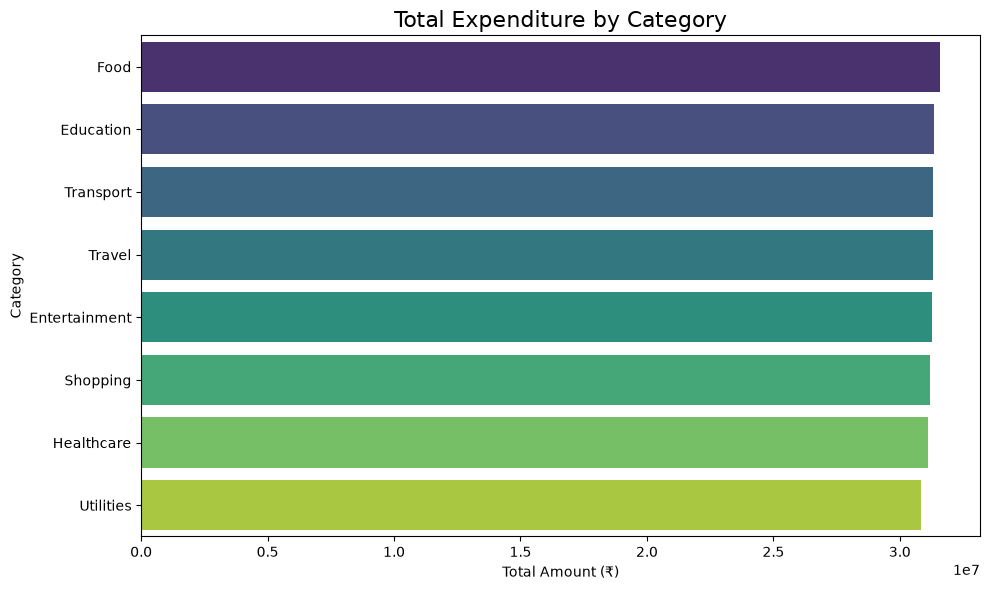

In [4]:
# Cell 4: Insight 1 - Total spend by category

category_spend = ddf.groupby('category')['amount'].sum().compute()
category_spend = category_spend.sort_values(ascending=False)

print("=== TOTAL SPEND BY CATEGORY ===")
print(category_spend)

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(x=category_spend.values, y=category_spend.index, hue=category_spend.index, palette='viridis', legend=False)
plt.title('Total Expenditure by Category', fontsize=16)
plt.xlabel('Total Amount (₹)')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('category_spend.png')
plt.show()

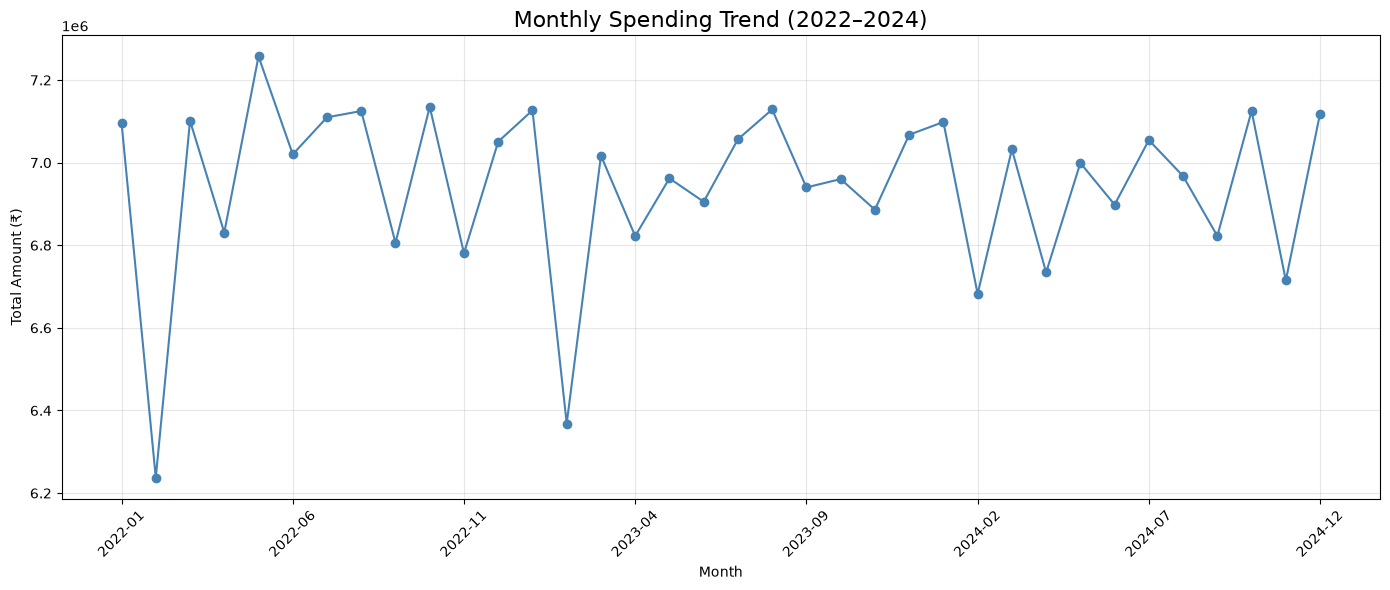

In [5]:
# Cell 5: Insight 2 - Monthly spending trend

# Extract month-year from date
ddf['month'] = ddf['date'].dt.to_period('M').astype(str)

monthly_spend = ddf.groupby('month')['amount'].sum().compute()
monthly_spend = monthly_spend.sort_index()

plt.figure(figsize=(14, 6))
monthly_spend.plot(kind='line', marker='o', color='steelblue')
plt.title('Monthly Spending Trend (2022–2024)', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total Amount (₹)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_trend.png')
plt.show()

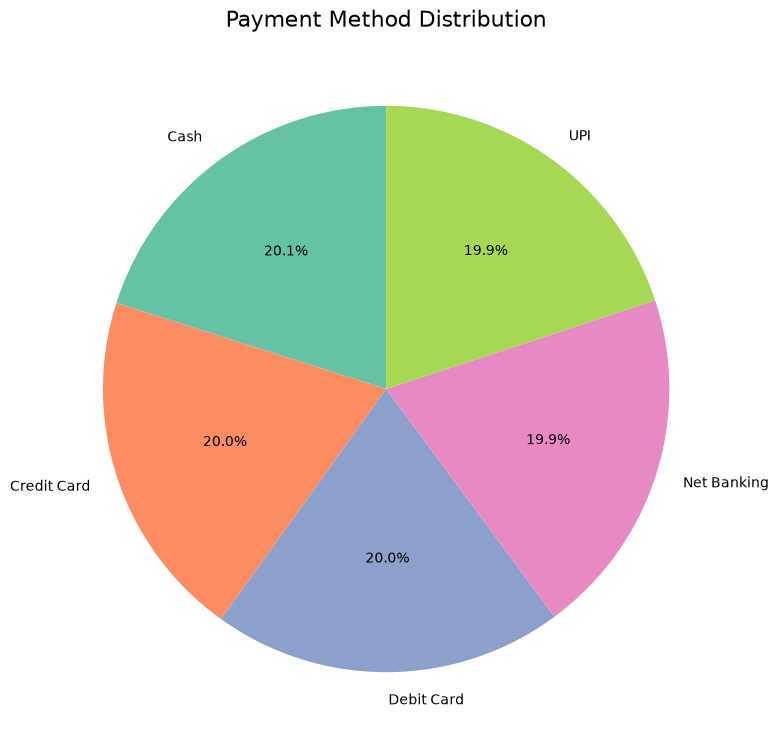

In [6]:
# Cell 6: Insight 3 - Payment method distribution

payment_counts = ddf['payment_method'].value_counts().compute()

plt.figure(figsize=(8, 8))
plt.pie(payment_counts.values, labels=payment_counts.index, 
        autopct='%1.1f%%', startangle=90,
        colors=sns.color_palette('Set2'))
plt.title('Payment Method Distribution', fontsize=16)
plt.tight_layout()
plt.savefig('payment_methods.png')
plt.show()

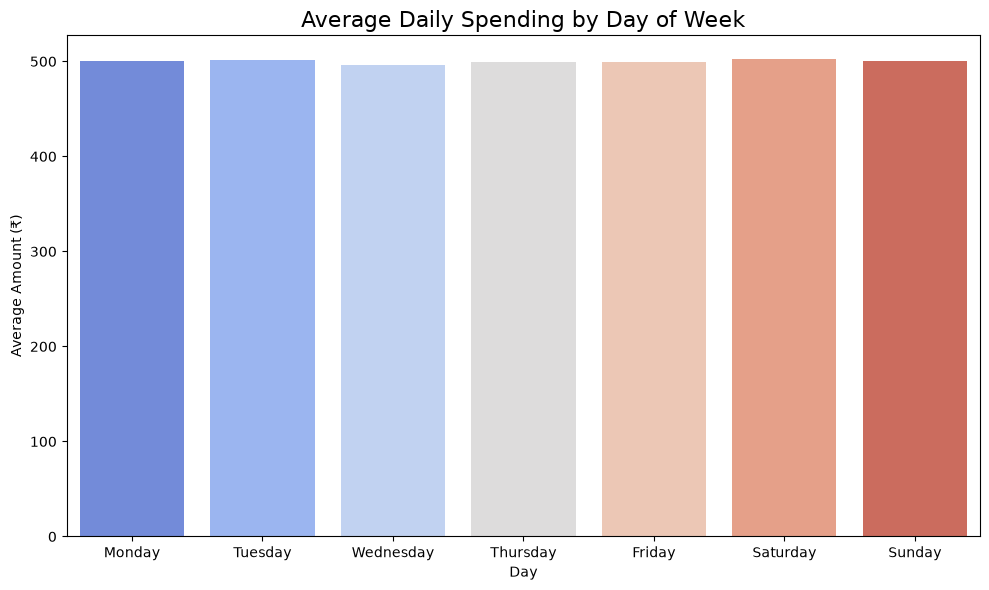

In [15]:
# Cell 7: Insight 4 - Day of week analysis

ddf['day_of_week'] = ddf['date'].dt.day_name()

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_spend = ddf.groupby('day_of_week')['amount'].mean().compute()
day_spend = day_spend.reindex(day_order)

plt.figure(figsize=(10, 6))
sns.barplot(x=day_spend.index, y=day_spend.values,hue=day_spend.index, palette='coolwarm', legend=False)
plt.title('Average Daily Spending by Day of Week', fontsize=16)
plt.xlabel('Day')
plt.ylabel('Average Amount (₹)')
plt.tight_layout()
plt.savefig('day_of_week.png')
plt.show()

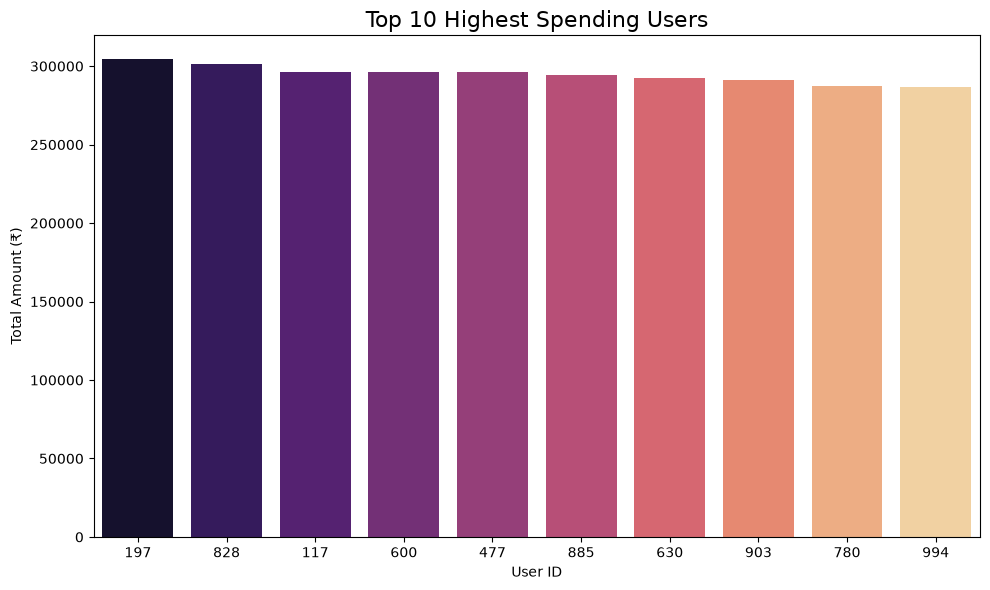

In [16]:
# Cell 8: Insight 5 - Top 10 highest spending users

top_users = ddf.groupby('user_id')['amount'].sum().compute()
top_users = top_users.nlargest(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_users.index.astype(str), y=top_users.values,hue=top_users.index.astype(str), palette='magma', legend=False)
plt.title('Top 10 Highest Spending Users', fontsize=16)
plt.xlabel('User ID')
plt.ylabel('Total Amount (₹)')
plt.tight_layout()
plt.savefig('top_users.png')
plt.show()

In [17]:
# Cell 9: Summary Insights (print your findings)

total = ddf['amount'].sum().compute()
avg = ddf['amount'].mean().compute()
top_cat = category_spend.idxmax()
top_month = monthly_spend.idxmax()

print("=" * 50)
print("KEY INSIGHTS FROM BIG DATA ANALYSIS")
print("=" * 50)
print(f"Total Transactions Analyzed : {len(ddf):,}")
print(f"Total Expenditure           : ₹{total:,.2f}")
print(f"Average Transaction Amount  : ₹{avg:,.2f}")
print(f"Highest Spending Category   : {top_cat}")
print(f"Peak Spending Month         : {top_month}")
print("=" * 50)

KEY INSIGHTS FROM BIG DATA ANALYSIS
Total Transactions Analyzed : 500,000
Total Expenditure           : ₹250,039,224.35
Average Transaction Amount  : ₹500.08
Highest Spending Category   : Food
Peak Spending Month         : 2022-05
